#Travelling Salesman Problem

"Given a list of cities and the distances between each pair of cities, what is the shortest possible route that visits each city exactly once and returns to the origin city?"

<img src="https://optimization.cbe.cornell.edu/images/e/ea/48StatesTSP.png">

In [ ]:
class City:
  def __init__(self,name,x,y):
    self.name = name
    self.logitude = x
    self.latitude = y

In [ ]:
example1= City('Seattle', 46.6062, -122.3321)
vars(example1)

{'name': 'Seattle', 'logitude': 46.6062, 'latitude': -122.3321}

In [ ]:
example1

In [ ]:
class City:
  def __init__(self,name,x,y):
    self.name = name
    self.logitude = x
    self.latitude = y
  def __str__(self):
      return self.name
  def __repr__(self):
      return '{0},({1}, {2})'.format(self.name, self.logitude, self.latitude)

In [ ]:
example1= City('Seattle', 47.6062, -122.3321)
example1

Seattle,(47.6062, -122.3321)

In [ ]:
example2= City('Houston', -95.3701, 29.7601)
example2

Houston,(-95.3701, 29.7601)

In [ ]:
pow((-122.3321-(-95.3701))**2+(47.6062-29.7601)**2, 0.5)

32.33315216940656

In [ ]:
class City:
  def __init__(self,name,x,y):
    self.name = name
    self.logitude = x
    self.latitude = y
  def __str__(self):
      return self.name
  def __repr__(self):
      return '{0},({1}, {2})'.format(self.name, self.logitude, self.latitude)

  def distance2city(self, city):
    deltax=self.logitude-city.logitude
    deltay=self.latitude-city.latitude
    return pow((deltax**2+deltay**2), 0.5)

In [ ]:
example1= City('Seattle',-122.3321, 47.6062)
example2= City('Houston', -95.3701, 29.7601)
example1.distance2city(example2)

32.33315216940656

In [ ]:
!pip install geopy

In [ ]:
places = [
    ('Mexico City', 19.4326, -99.1332),
    ('Bogota', 4.7110, -74.0721),
    ('Austin', 30.2672, -97.7431),
    ('Tirana', 41.3275, 19.8187),
    ('Skopje', 41.9981, 21.4254),
    ('Rivera', -30.9060, -55.5506),
    ('Cordoba', -31.4201, -64.1888),
    ('Houston', 29.7604, -95.3698),
    ('Almaty', 43.2565, 76.9285),
    ('Buenos Aires', -34.6037, -58.3816),
    ('Baghdad', 33.3152, 44.3661),
    ('Delhi', 28.7041, 77.1025),
    ('Guangzhou', 23.1300, 113.2600),
    ('Shanghai', 31.2304, 121.4737),
    ('Manila', 14.5995, 120.9842),
    ('Mumbai', 19.0760, 72.8777),
    ('Banglore', 12.9716, 77.5946),
    ('Belgaum', 15.8497, 74.4977),
    ('Singapore', 1.3521, 103.8198),
    ('Lahore', 31.5497, 74.3436),
    ('Asuncion', -25.2637, -57.5759)

In [ ]:
# from geopy.geocoders import Nominatim
# geolocator = Nominatim(user_agent='my_app_1', timeout=2)
# location= geolocator.geocode(places[0])
# print((location.longitude, location.latitude))

In [ ]:
# This cell is no longer needed as we are using predefined coordinates
# import warnings
# warnings.filterwarnings('ignore')

# for place in places:
#   try:
#     location= geolocator.geocode(place)
#     print(place, (location.latitude,location.longitude))
#   except:
#     print(place, 'not found')

In [ ]:
import random

def nearest_neighbor_heuristic(cities):
    """
    Implements the Nearest Neighbor heuristic for the TSP.

    Args:
        cities: A list of City objects.

    Returns:
        A list of City objects representing the approximate shortest route.
    """
    num_cities = len(cities)
    if num_cities < 2:
        return cities

    # Start at a random city
    start_city = random.choice(cities)
    unvisited_cities = set(cities)
    unvisited_cities.remove(start_city)
    route = [start_city]

    current_city = start_city
    while unvisited_cities:
        nearest_city = min(unvisited_cities, key=lambda city: current_city.distance2city(city))
        route.append(nearest_city)
        unvisited_cities.remove(nearest_city)
        current_city = nearest_city

    return route

In [ ]:
Cities = [City(name, lon, lat) for name, lat, lon in places]

In [ ]:
Cities

[Mexico City,(-99.1332, 19.4326),
 Bogota,(-74.0721, 4.711),
 Austin,(-97.7431, 30.2672),
 Tirana,(19.8187, 41.3275),
 Skopje,(21.4254, 41.9981),
 Rivera,(-55.5506, -30.906),
 Cordoba,(-64.1888, -31.4201),
 Houston,(-95.3698, 29.7604),
 Almaty,(76.9285, 43.2565),
 Buenos Aires,(-58.3816, -34.6037),
 Baghdad,(44.3661, 33.3152),
 Delhi,(77.1025, 28.7041),
 Guangzhou,(113.26, 23.13),
 Shanghai,(121.4737, 31.2304),
 Manila,(120.9842, 14.5995),
 Mumbai,(72.8777, 19.076),
 Banglore,(77.5946, 12.9716),
 Belgaum,(74.4977, 15.8497),
 Singapore,(103.8198, 1.3521),
 Lahore,(74.3436, 31.5497),
 Asuncion,(-57.5759, -25.2637)]

In [ ]:
world="https://raw.githubusercontent.com/edavgaun/RCEL_506/refs/heads/main/Module%204/worldmap.geojson"

In [ ]:
import geopandas as gdp
world_map=gdp.read_file(world)

In [ ]:
world_map=gdp.read_file(world)

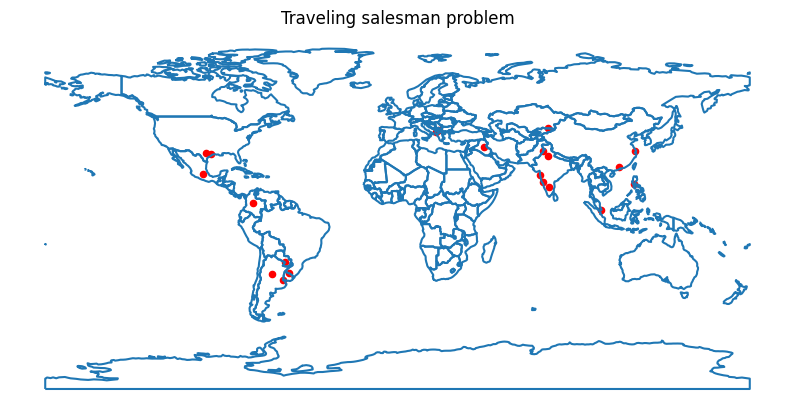

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1,1,figsize=(10,10))
world_map.boundary.plot(ax=axs)
for city in Cities:
  axs.scatter(city.logitude, city.latitude, s=20, color='red')
axs.set_title("Traveling salesman problem")
axs.axis('off')
plt.show()

In [ ]:
type(Cities[0])

__main__.City

In [ ]:
import pandas as pd
df_cities=pd.DataFrame({'Place':city.name,
                        'Long': city.logitude,
                        'Lat': city.latitude}
                        for city in Cities)
df_cities=df_cities.sort_values('Place').reset_index(drop=True)

In [ ]:
df_cities

,Place,Long,Lat
0,Almaty,76.9285,43.2565
1,Asuncion,-57.5759,-25.2637
2,Austin,-97.7431,30.2672
3,Baghdad,44.3661,33.3152
4,Banglore,77.5946,12.9716
5,Belgaum,74.4977,15.8497
6,Bogota,-74.0721,4.7110
7,Buenos Aires,-58.3816,-34.6037
8,Cordoba,-64.1888,-31.4201
9,Delhi,77.1025,28.7041


In [ ]:
def Plot_TSPMap(axs, df=None, base_line=False,
                title='Traveling salesman problem, \n Base-Line Solution'):
  world_map.boundary.plot(ax=axs)
  for city in Cities:
    axs.scatter(city.logitude, city.latitude, s=20, color='red')
  if base_line and df is not None:
    for i in range(df.shape[0]-1):
      axs.plot([df.iloc[i,1],df.iloc[i+1,1]],
               [df.iloc[i,2],df.iloc[i+1,2]],
                color='orange')
    # Plot line from last city back to the first city to close the loop
    axs.plot([df.iloc[df.shape[0]-1,1],df.iloc[0,1]],
             [df.iloc[df.shape[0]-1,2],df.iloc[0,2]],
              color='orange')
  axs.set_title(title)
  axs.axis('off')

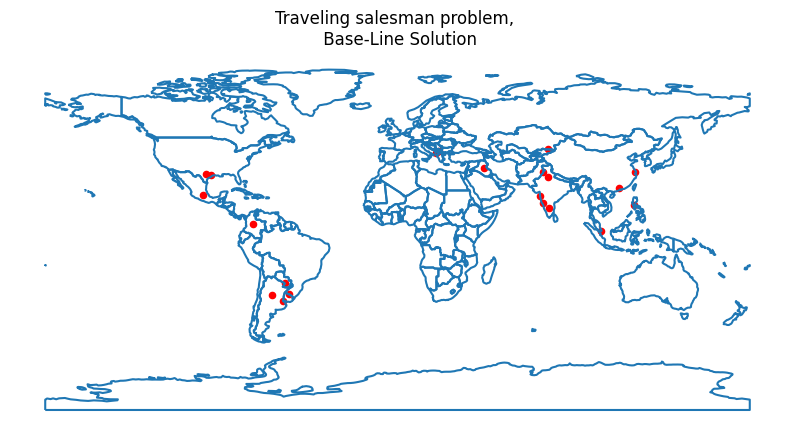

In [ ]:
fig,axs = plt.subplots(1,1,figsize=(10,10))
Plot_TSPMap(axs, df_cities)
plt.show()

In [ ]:
class Fitness:
  def __init__(self, route):
    self.total_distance = self.Calculate_Total_Distance(route)
    self.fitness_value=self.Calculate_Fitness()

  def Calculate_Total_Distance(self, route):
    path_distance=0
    for i in range(0,len(route)):
      from_city=route[i]
      if i+1<len(route):
        to_city=route[i+1]
      else:
        to_city=route[0]
      path_distance+=from_city.distance2city(to_city)
    return path_distance
  def Calculate_Fitness(self):
    return 1/(self.total_distance+1)

In [ ]:
Cities

[Mexico City,(-99.1332, 19.4326),
 Bogota,(-74.0721, 4.711),
 Austin,(-97.7431, 30.2672),
 Tirana,(19.8187, 41.3275),
 Skopje,(21.4254, 41.9981),
 Rivera,(-55.5506, -30.906),
 Cordoba,(-64.1888, -31.4201),
 Houston,(-95.3698, 29.7604),
 Almaty,(76.9285, 43.2565),
 Buenos Aires,(-58.3816, -34.6037),
 Baghdad,(44.3661, 33.3152),
 Delhi,(77.1025, 28.7041),
 Guangzhou,(113.26, 23.13),
 Shanghai,(121.4737, 31.2304),
 Manila,(120.9842, 14.5995),
 Mumbai,(72.8777, 19.076),
 Banglore,(77.5946, 12.9716),
 Belgaum,(74.4977, 15.8497),
 Singapore,(103.8198, 1.3521),
 Lahore,(74.3436, 31.5497),
 Asuncion,(-57.5759, -25.2637)]

In [ ]:
df_cities.values[0]

array(['Almaty', 76.9285, 43.2565], dtype=object)

In [ ]:
base_solution=[City(city[0], city[1], city[2])for city in df_cities.values]

In [ ]:
Fitness(base_solution).total_distance

2124.0452873800923

In [ ]:
Fitness(Cities).total_distance

1256.816884232307

In [ ]:
Fitness(base_solution).fitness_value

0.00047057820646865904

In [ ]:
Fitness(Cities).fitness_value

0.0007950282847493637

In [ ]:
def plot_route(axs, route):
  """
  Plots a given route on the world map.

  Args:
      axs: The axes object to plot on.
      route: A list of City objects representing the route.
  """
  for i in range(len(route) - 1):
    axs.plot([route[i].logitude, route[i+1].logitude],
             [route[i].latitude, route[i+1].latitude],
             color='blue', linestyle='-', linewidth=1)
  # Plot line from the last city back to the first city to close the loop
  axs.plot([route[-1].logitude, route[0].logitude],
           [route[-1].latitude, route[0].latitude],
           color='blue', linestyle='-', linewidth=1)

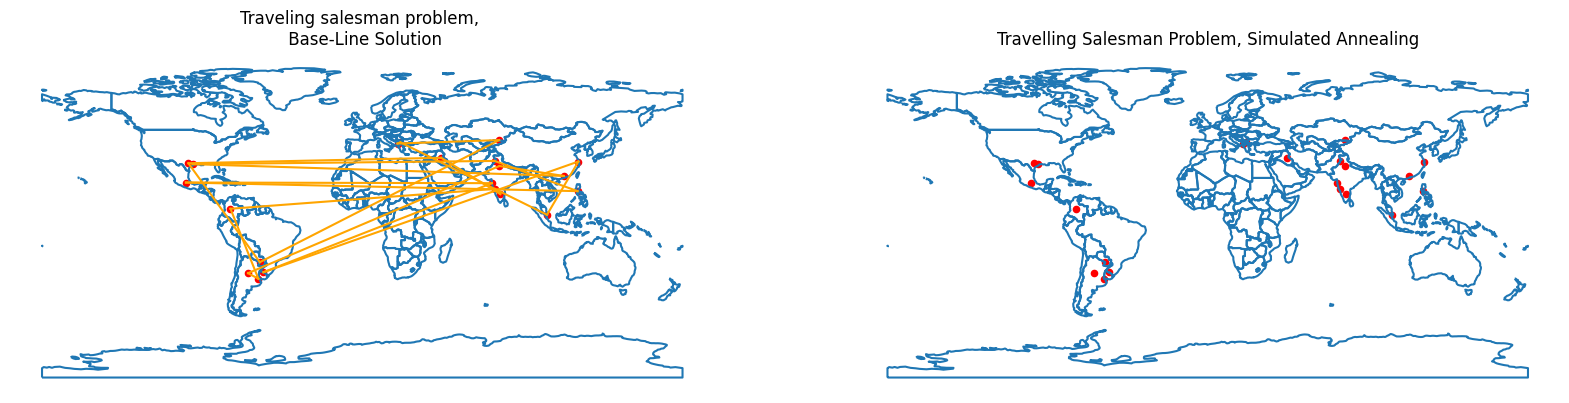

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(20, 10)) # Unpack fig and axs separately
Plot_TSPMap(axs[0], df_cities, base_line=True)
Plot_TSPMap(axs[1], df_cities, base_line=False,
            title='Travelling Salesman Problem, Simulated Annealing')
plt.show()

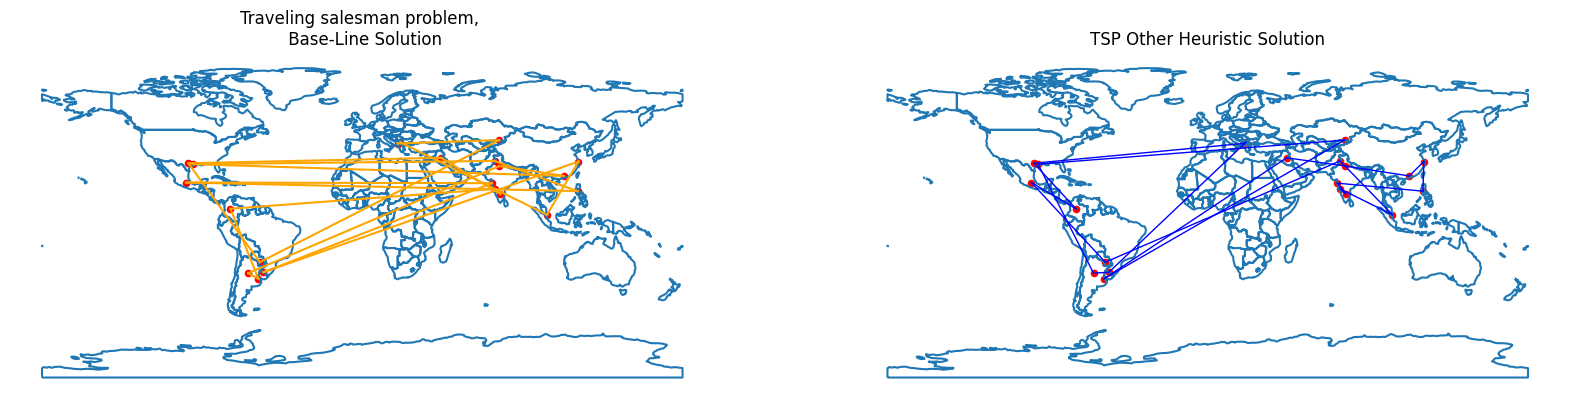

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(20,10))
Plot_TSPMap(axs[0],df_cities,base_line=True)
Plot_TSPMap(axs[1],df_cities, base_line=False,
            title='TSP Other Heuristic Solution')
plot_route(axs[1], Cities)
plt.show()

#Class Module 8

In [ ]:
Cities

[Mexico City,(-99.1332, 19.4326),
 Bogota,(-74.0721, 4.711),
 Austin,(-97.7431, 30.2672),
 Tirana,(19.8187, 41.3275),
 Skopje,(21.4254, 41.9981),
 Rivera,(-55.5506, -30.906),
 Cordoba,(-64.1888, -31.4201),
 Houston,(-95.3698, 29.7604),
 Almaty,(76.9285, 43.2565),
 Buenos Aires,(-58.3816, -34.6037),
 Baghdad,(44.3661, 33.3152),
 Delhi,(77.1025, 28.7041),
 Guangzhou,(113.26, 23.13),
 Shanghai,(121.4737, 31.2304),
 Manila,(120.9842, 14.5995),
 Mumbai,(72.8777, 19.076),
 Banglore,(77.5946, 12.9716),
 Belgaum,(74.4977, 15.8497),
 Singapore,(103.8198, 1.3521),
 Lahore,(74.3436, 31.5497),
 Asuncion,(-57.5759, -25.2637)]

In [ ]:
Fitness(base_solution).fitness_value

0.00047057820646865904

In [ ]:
Fitness(Cities).fitness_value

0.0007950282847493637

#Solving the TSP
<img src="https://www.mdpi.com/symmetry/symmetry-12-01758/article_deploy/html/images/symmetry-12-01758-g001-550.jpg">

* An individual ->  Solution(Route)
* Genes -> City
* population -> Group of solutions
* generation -> Group of population
Over time
* Mutation -> 2 Genes that change place
* Elite -> The top individual from population
* Breeding -> Creating a new solution using 2 solution

In [ ]:
import numpy as np

np.random.seed(0)

print(base_solution)
print("-"*2000)
print(list(np.random.choice(Cities, replace=False, size= len(Cities))))

[Almaty,(76.9285, 43.2565), Asuncion,(-57.5759, -25.2637), Austin,(-97.7431, 30.2672), Baghdad,(44.3661, 33.3152), Banglore,(77.5946, 12.9716), Belgaum,(74.4977, 15.8497), Bogota,(-74.0721, 4.711), Buenos Aires,(-58.3816, -34.6037), Cordoba,(-64.1888, -31.4201), Delhi,(77.1025, 28.7041), Guangzhou,(113.26, 23.13), Houston,(-95.3698, 29.7604), Lahore,(74.3436, 31.5497), Manila,(120.9842, 14.5995), Mexico City,(-99.1332, 19.4326), Mumbai,(72.8777, 19.076), Rivera,(-55.5506, -30.906), Shanghai,(121.4737, 31.2304), Singapore,(103.8198, 1.3521), Skopje,(21.4254, 41.9981), Tirana,(19.8187, 41.3275)]
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
len(Cities)

21

In [ ]:
def first_generation(num_ind, base_line_ind):
  pop={0:base_line_ind}
  for i in range(1, num_ind):
    pop[i]=list(np.random.choice(base_solution,
                                 replace= False,
                                 size=len(base_line_ind)))
  return pop


In [ ]:
np.random.seed(0)
gen1 = first_generation(20,base_solution)

In [ ]:
def ranking_individuals(generation):
  df_gen=pd.DataFrame({"individual_id": generation.keys(),
                      "Route": generation.values()})
  df_gen['Fitness']=df_gen['Route'].apply(lambda x: Fitness(x).fitness_value)
  return df_gen.sort_values('Fitness', ascending=False).reset_index(drop=True)

ranking_individuals(gen1)

,individual_id,Route,Fitness
0,8,"[Buenos Aires, Asuncion, Belgaum, Banglore, Si...",0.000600
1,12,"[Almaty, Guangzhou, Belgaum, Bogota, Skopje, A...",0.000584
2,18,"[Austin, Mexico City, Delhi, Rivera, Lahore, T...",0.000527
3,3,"[Manila, Singapore, Skopje, Bogota, Rivera, Be...",0.000520
4,17,"[Tirana, Baghdad, Rivera, Houston, Belgaum, De...",0.000498
5,2,"[Bogota, Tirana, Rivera, Guangzhou, Buenos Air...",0.000494
6,9,"[Skopje, Rivera, Manila, Buenos Aires, Asuncio...",0.000483
7,19,"[Mexico City, Shanghai, Delhi, Buenos Aires, M...",0.000474
8,0,"[Almaty, Asuncion, Austin, Baghdad, Banglore, ...",0.000471
9,15,"[Almaty, Cordoba, Delhi, Mexico City, Baghdad,...",0.000458


In [ ]:
def breeding_individual(RankedGen, elitesize=6):
  elite_ind = list(RankedGen['individual_id'].values[:elitesize])
  for i in range(elitesize, len(RankedGen)):
    elite_ind.append(np.random.randint(0, len(RankedGen)))
  return [int(ind) for ind in elite_ind]

np.random.seed(10)

breeding_individual(ranking_individuals(gen1))

[8, 12, 18, 3, 17, 2, 9, 4, 15, 0, 17, 16, 17, 8, 9, 0, 10, 8, 4, 19]

In [ ]:
from random import randint
#parentA : gene1, gene2, gene3, gene4,gene5,gene6,gene7 -> cossover
#parentB : gene8, gene9, gene3, gene9,gene8,gene7,gene6 -> for loop

#Offspring: gene3, gene4, gene5, gene6, || gene2, gene1, gene7

def Crossover(parent1, parent2):
  genesA=[]
  n1=np.random.randint(0, len(parent1))
  n2=np.random.randint(0, len(parent2))
  lower=min(n1,n2)
  upper=max(n1,n2)
  genesA= parent1[lower:upper]
  genesB= [gene for gene in parent2 if gene not in genesA]
  offspring=genesA+genesB
  return offspring

In [ ]:
print(gen1[8])
print(gen1[0])
print("-"*2000)
print(Crossover(gen1[8], gen1[0]))

[Buenos Aires,(-58.3816, -34.6037), Asuncion,(-57.5759, -25.2637), Belgaum,(74.4977, 15.8497), Banglore,(77.5946, 12.9716), Singapore,(103.8198, 1.3521), Mumbai,(72.8777, 19.076), Delhi,(77.1025, 28.7041), Shanghai,(121.4737, 31.2304), Tirana,(19.8187, 41.3275), Austin,(-97.7431, 30.2672), Houston,(-95.3698, 29.7604), Manila,(120.9842, 14.5995), Lahore,(74.3436, 31.5497), Cordoba,(-64.1888, -31.4201), Baghdad,(44.3661, 33.3152), Guangzhou,(113.26, 23.13), Mexico City,(-99.1332, 19.4326), Bogota,(-74.0721, 4.711), Skopje,(21.4254, 41.9981), Almaty,(76.9285, 43.2565), Rivera,(-55.5506, -30.906)]
[Almaty,(76.9285, 43.2565), Asuncion,(-57.5759, -25.2637), Austin,(-97.7431, 30.2672), Baghdad,(44.3661, 33.3152), Banglore,(77.5946, 12.9716), Belgaum,(74.4977, 15.8497), Bogota,(-74.0721, 4.711), Buenos Aires,(-58.3816, -34.6037), Cordoba,(-64.1888, -31.4201), Delhi,(77.1025, 28.7041), Guangzhou,(113.26, 23.13), Houston,(-95.3698, 29.7604), Lahore,(74.3436, 31.5497), Manila,(120.9842, 14.5995),

In [ ]:
print(gen1[8])
print(gen1[0])
print("-"*2000)
print(Crossover(gen1[0], gen1[10]))

[Buenos Aires,(-58.3816, -34.6037), Asuncion,(-57.5759, -25.2637), Belgaum,(74.4977, 15.8497), Banglore,(77.5946, 12.9716), Singapore,(103.8198, 1.3521), Mumbai,(72.8777, 19.076), Delhi,(77.1025, 28.7041), Shanghai,(121.4737, 31.2304), Tirana,(19.8187, 41.3275), Austin,(-97.7431, 30.2672), Houston,(-95.3698, 29.7604), Manila,(120.9842, 14.5995), Lahore,(74.3436, 31.5497), Cordoba,(-64.1888, -31.4201), Baghdad,(44.3661, 33.3152), Guangzhou,(113.26, 23.13), Mexico City,(-99.1332, 19.4326), Bogota,(-74.0721, 4.711), Skopje,(21.4254, 41.9981), Almaty,(76.9285, 43.2565), Rivera,(-55.5506, -30.906)]
[Almaty,(76.9285, 43.2565), Asuncion,(-57.5759, -25.2637), Austin,(-97.7431, 30.2672), Baghdad,(44.3661, 33.3152), Banglore,(77.5946, 12.9716), Belgaum,(74.4977, 15.8497), Bogota,(-74.0721, 4.711), Buenos Aires,(-58.3816, -34.6037), Cordoba,(-64.1888, -31.4201), Delhi,(77.1025, 28.7041), Guangzhou,(113.26, 23.13), Houston,(-95.3698, 29.7604), Lahore,(74.3436, 31.5497), Manila,(120.9842, 14.5995),

In [ ]:
def new_generation(RankedGen, elitesize=6):
  mating_inds=breeding_individual(RankedGen, elitesize)
  new_gen={}

  for i in range(elitesize):
    k, v = RankedGen.loc[i,['individual_id','Route']].values
    new_gen[k]=v
  n_max=RankedGen['individual_id'].max()

  while len(new_gen)<len(RankedGen):
    try:
      elitesize+=1
      p1=np.random.choice(mating_inds)
      p2=np.random.choice(mating_inds)

      child=Crossover(
                 RankedGen[RankedGen['individual_id']==p1]['Route'].values[0],
                 RankedGen[RankedGen['individual_id']==p2]['Route'].values[0])
      new_gen[n_max+elitesize]=child
    except:
      continue

  return new_gen

gen1_ranked=ranking_individuals(gen1)
new_gen=new_generation(gen1_ranked)
len(new_gen)

20

In [ ]:
def GA(num_ind, num_gen, base_line_ind, elitesize=6):
 generation=first_generation(num_ind, base_line_ind)
 top_ind_pergen={}

 for i in range(num_gen):
  generation_ranked=ranking_individuals(generation)
  generation=new_generation(generation_ranked, elitesize)
  id=generation_ranked.individual_id[0]
  path=generation_ranked.Route[0]
  fv=generation_ranked.Fitness[0]
  top_ind_pergen[i]=[id, path, fv]

 return generation, top_ind_pergen

In [ ]:
result= GA(25,200, base_solution,10)

In [ ]:
max(result[0])

20263

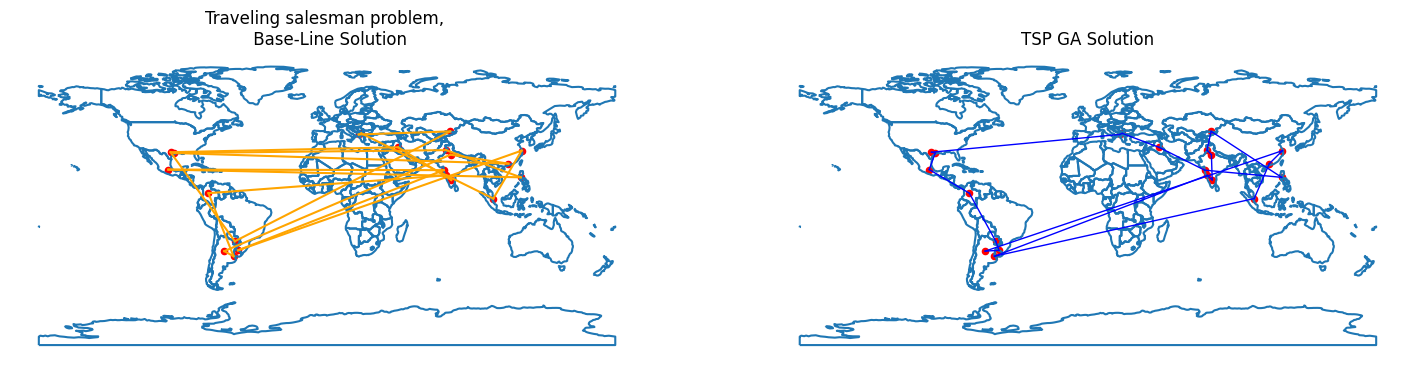

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(18,10))
Plot_TSPMap(axs[0],df_cities,base_line=True)
Plot_TSPMap(axs[1],df_cities, base_line=False,
            title='TSP GA Solution')
plot_route(axs[1], result[0][20263])
plt.show()